<a href="https://colab.research.google.com/github/muhammadmalikakbar/UTS_PengolahanCitraDigital_23423014/blob/main/UTSPengolahanCitraDigital_23423014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NO 1**

In [1]:
import cv2
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


Image converted to grayscale.


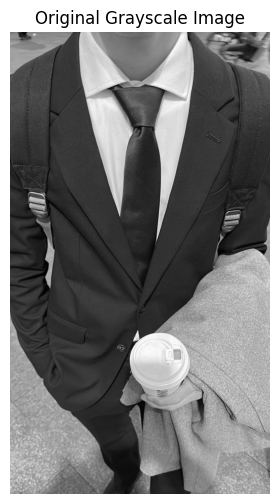

In [2]:
image_path = '/content/priajas.jpeg'
original_image = cv2.imread(image_path)

# Check if the image was loaded successfully
if original_image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert to grayscale if not already (check number of channels)
    if len(original_image.shape) == 3:
        # Image has 3 channels (e.g., BGR from cv2.imread), convert to grayscale
        grayscale_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
        print("Image converted to grayscale.")
    else:
        # Image is already grayscale
        grayscale_image = original_image
        print("Image is already grayscale.")

    # Display the original grayscale image
    plt.figure(figsize=(8, 6))
    plt.imshow(grayscale_image, cmap='gray')
    plt.title('Original Grayscale Image')
    plt.axis('off') # Hide axes ticks
    plt.show()


In [3]:
negative_image = 255 - grayscale_image
print("Negative transformation applied successfully.")

Negative transformation applied successfully.


In [4]:
import numpy as np

# Step 1: Find the maximum pixel value in the grayscale_image
max_pixel_value = np.max(grayscale_image)

# Step 2: Calculate the constant c
c = 255 / np.log(1 + max_pixel_value)

# Step 3: Apply the logarithmic transformation G = c * log(1 + F)
# Convert grayscale_image to float32 for accurate log calculation
log_transformed_image = c * np.log(1 + grayscale_image.astype(np.float32))

# Step 4: Convert the result back to uint8 and ensure values are within [0, 255]
log_transformed_image = np.array(log_transformed_image, dtype=np.uint8)

print("Logarithmic transformation applied successfully.")

Logarithmic transformation applied successfully.


/tmp/ipython-input-1596226640.py:7: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + max_pixel_value)
/tmp/ipython-input-1596226640.py:7: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + max_pixel_value)


In [5]:
import numpy as np

# Step 1: Find the maximum pixel value in the grayscale_image
max_pixel_value = np.max(grayscale_image)

if max_pixel_value == 0:
    # If the image is completely black, log transformation will also be all black
    log_transformed_image = np.zeros_like(grayscale_image, dtype=np.uint8)
    print("Image is all black. Logarithmic transformation results in all black image.")
else:
    # Step 2: Calculate the constant c
    # Convert max_pixel_value to float to ensure float division and prevent warnings
    c = 255.0 / np.log(1.0 + max_pixel_value)

    # Step 3: Apply the logarithmic transformation G = c * log(1 + F)
    # Convert grayscale_image to float32 for accurate log calculation
    log_transformed_image = c * np.log(1.0 + grayscale_image.astype(np.float32))

    # Step 4: Convert the result back to uint8 and ensure values are within [0, 255]
    log_transformed_image = np.array(log_transformed_image, dtype=np.uint8)
    print("Logarithmic transformation applied successfully.")

Logarithmic transformation applied successfully.


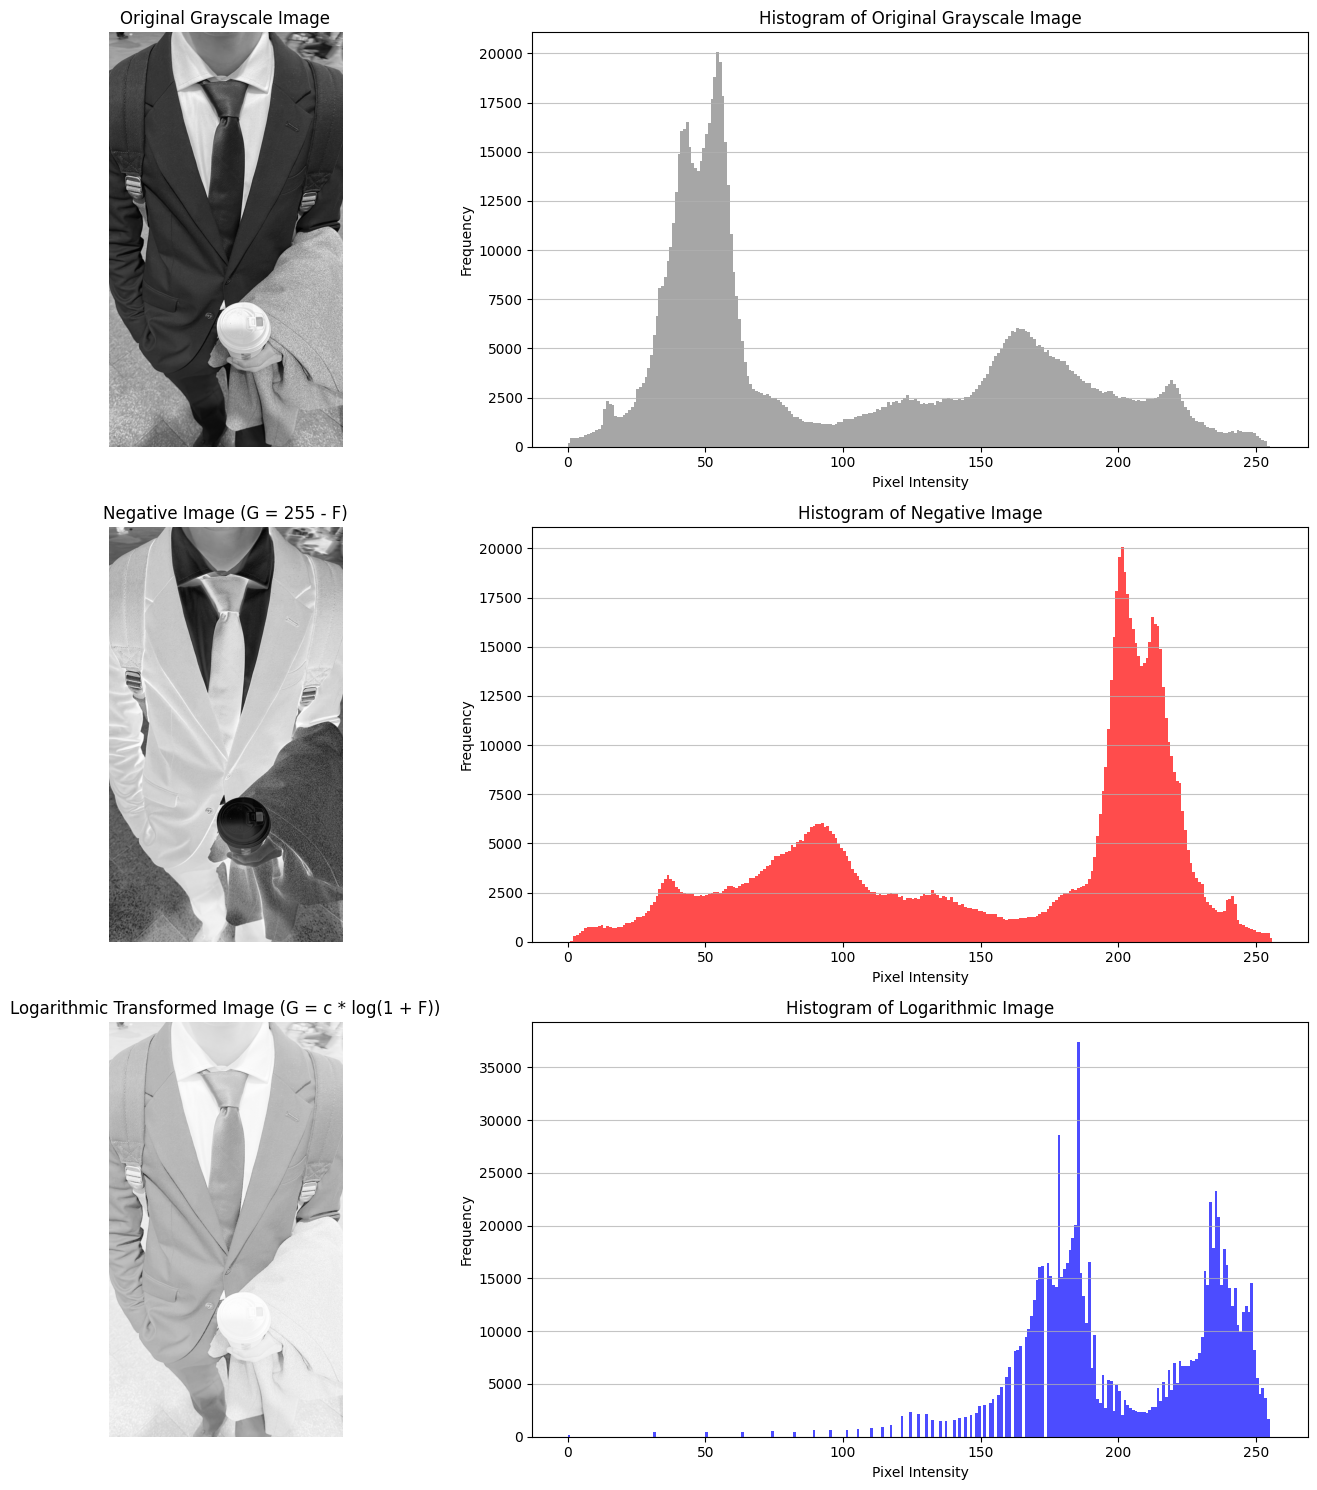

In [6]:
import matplotlib.pyplot as plt

# Create a figure with 3 rows and 2 columns
plt.figure(figsize=(15, 15))

# --- Original Grayscale Image and its Histogram ---

# Plot Original Grayscale Image
plt.subplot(3, 2, 1) # 3 rows, 2 columns, 1st subplot
plt.imshow(grayscale_image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

# Plot Histogram of Original Grayscale Image
plt.subplot(3, 2, 2) # 3 rows, 2 columns, 2nd subplot
plt.hist(grayscale_image.ravel(), bins=256, range=(0, 256), color='gray', alpha=0.7)
plt.title('Histogram of Original Grayscale Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# --- Negative Image and its Histogram ---

# Plot Negative Image
plt.subplot(3, 2, 3) # 3 rows, 2 columns, 3rd subplot
plt.imshow(negative_image, cmap='gray')
plt.title('Negative Image (G = 255 - F)')
plt.axis('off')

# Plot Histogram of Negative Image
plt.subplot(3, 2, 4) # 3 rows, 2 columns, 4th subplot
plt.hist(negative_image.ravel(), bins=256, range=(0, 256), color='red', alpha=0.7)
plt.title('Histogram of Negative Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# --- Logarithmic Image and its Histogram ---

# Plot Logarithmic Image
plt.subplot(3, 2, 5) # 3 rows, 2 columns, 5th subplot
plt.imshow(log_transformed_image, cmap='gray')
plt.title('Logarithmic Transformed Image (G = c * log(1 + F))')
plt.axis('off')

# Plot Histogram of Logarithmic Image
plt.subplot(3, 2, 6) # 3 rows, 2 columns, 6th subplot
plt.hist(log_transformed_image.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
plt.title('Histogram of Logarithmic Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Display the plots
plt.show()

In [7]:
analysis_content = """### Analysis of Image Transformations\n\n**1. Visual Differences and Pixel Intensity Distribution:**\n\n*   **Original Grayscale Image:** The original image displays a certain range of pixel intensities, typically with a histogram showing the distribution of these values. Visually, it represents the scene as captured, with pixel values distributed across the 0-255 range. The histogram for the original image shows the frequency of each intensity level, indicating the overall brightness and contrast characteristics.\n\n*   **Negative Image (G = 255 - F):** The negative transformation inverts the pixel intensities. Dark areas become bright, and bright areas become dark. Visually, the image appears like a photographic negative. Its histogram is a mirror image of the original image's histogram; if the original had many dark pixels, the negative image will have many bright pixels, and vice-versa. This transformation is straightforward and effectively reverses the intensity scale.\n\n*   **Logarithmic Transformed Image (G = c * log(1 + F)):** The logarithmic transformation enhances the details in the darker regions of the image while compressing the brighter regions. Visually, areas that were originally dark become brighter and more distinct, while very bright areas might appear somewhat desaturated or less contrasted compared to the original. The histogram for the logarithmic image typically shows a shift of pixel values towards the higher intensity (brighter) end, indicating that dark pixels have been expanded and bright pixels have been compressed into a narrower range of higher values.\n\n**2. Comparing Negative and Logarithmic Transformation Effects:**\n\n*   **Negative Transformation:** Primarily used for image enhancement by inverting intensities. It's useful for visualizing details in images where important information is embedded in very dark or very bright regions that are hard to discern. For example, in medical imaging (like X-rays), inverting might make certain features more apparent. It's a linear transformation of intensity values.\n\n*   **Logarithmic Transformation:** This is a non-linear transformation. Its primary effect is to expand the range of dark pixel values and compress the range of bright pixel values. This makes details in the shadows more visible without saturating the highlights too much. It's particularly effective for images with a wide dynamic range, where significant detail is lost in the very dark areas, or where the overall image appears too dark.\n\n**3. When Logarithmic Transformation is More Beneficial than Negative:**\n\nLogarithmic transformation is generally more beneficial than negative transformation in scenarios where:\n\n*   **Images are predominantly dark:** If an image has a narrow range of dark pixel values, the logarithmic transformation will effectively spread out these values, making subtle differences in dark regions more distinguishable. The negative transformation would simply make these dark regions bright, but might not necessarily enhance the *contrast* within those originally dark (now bright) regions as effectively.\n*   **There is a need to enhance low-intensity detail:** Logarithmic transformation is excellent for bringing out details in the shadowed or under-exposed parts of an image. It increases the contrast in the darker areas at the expense of compressing the contrast in brighter areas.\n*   **Images have a wide dynamic range:** For images containing both very dark and very bright regions where details in the dark areas are crucial, the logarithmic transformation can make both visible by compressing the overall dynamic range into a more perceptible visual range.\n*   **Unlike negative transformation which simply inverts all values equally, logarithmic transformation applies a non-linear mapping that is specifically designed to highlight low-intensity information.** This makes it superior when the goal is to improve the visibility of features that are obscure due to being very dark, rather than just inverting the entire image's appearance.\n"""

# Save the analysis content to a file
file_path = 'image_analysis.txt'
with open(file_path, 'w') as f:
    f.write(analysis_content)

print(f"Analysis saved to '{file_path}' successfully.")

Analysis saved to 'image_analysis.txt' successfully.


**NO 2**

In [8]:
import numpy as np

# 2. Define a 3x3 Low Pass Filter (LPF) kernel (averaging filter)
lpf_kernel = np.ones((3, 3)) / 9
print(f"LPF Kernel:\n{lpf_kernel}")

# 3. Define a 3x3 High Pass Filter (HPF) kernel (Laplacian filter)
hpf_kernel = np.array([[-1, -1, -1],
                       [-1,  8, -1],
                       [-1, -1, -1]])
print(f"\nHPF Kernel:\n{hpf_kernel}")

# 4. Define a 3x3 Band Pass Filter (BPF) kernel (sharpening filter)
bpf_kernel = np.array([[ 0, -1,  0],
                       [-1,  5, -1],
                       [ 0, -1,  0]])
print(f"\nBPF Kernel:\n{bpf_kernel}")

print("Convolution kernels defined successfully.")

LPF Kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

HPF Kernel:
[[-1 -1 -1]
 [-1  8 -1]
 [-1 -1 -1]]

BPF Kernel:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]
Convolution kernels defined successfully.


In [9]:
import cv2

# Apply LPF kernel
lpf_image = cv2.filter2D(grayscale_image, -1, lpf_kernel)
print("Low Pass Filter applied successfully.")

# Apply HPF kernel
hpf_image = cv2.filter2D(grayscale_image, -1, hpf_kernel)
print("High Pass Filter applied successfully.")

# Apply BPF kernel (using the sharpening kernel as a BPF example)
bpf_image = cv2.filter2D(grayscale_image, -1, bpf_kernel)
print("Band Pass Filter applied successfully.")

Low Pass Filter applied successfully.
High Pass Filter applied successfully.
Band Pass Filter applied successfully.


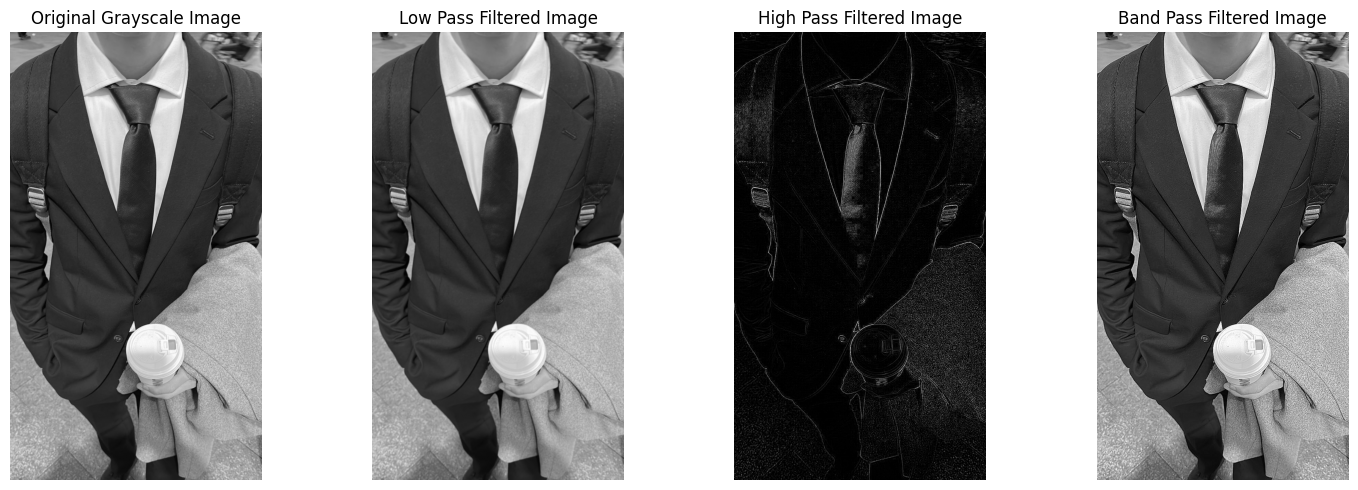

Visualized original and filtered images successfully.


In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Original Grayscale Image
plt.subplot(1, 4, 1)
plt.imshow(grayscale_image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

# LPF Image
plt.subplot(1, 4, 2)
plt.imshow(lpf_image, cmap='gray')
plt.title('Low Pass Filtered Image')
plt.axis('off')

# HPF Image
plt.subplot(1, 4, 3)
plt.imshow(hpf_image, cmap='gray')
plt.title('High Pass Filtered Image')
plt.axis('off')

# BPF Image
plt.subplot(1, 4, 4)
plt.imshow(bpf_image, cmap='gray')
plt.title('Band Pass Filtered Image')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Visualized original and filtered images successfully.")

In [11]:
print(f"Average pixel intensity of Original Grayscale Image: {np.mean(grayscale_image):.2f}")
print(f"Average pixel intensity of LPF Image: {np.mean(lpf_image):.2f}")
print(f"Average pixel intensity of HPF Image: {np.mean(hpf_image):.2f}")
print(f"Average pixel intensity of BPF Image: {np.mean(bpf_image):.2f}")

print("Average pixel intensities calculated successfully.")

Average pixel intensity of Original Grayscale Image: 101.20
Average pixel intensity of LPF Image: 101.20
Average pixel intensity of HPF Image: 12.38
Average pixel intensity of BPF Image: 101.62
Average pixel intensities calculated successfully.


### Analysis of Convolution Filters: LPF, HPF, and BPF

#### 1. Low Pass Filter (LPF) - Smoothing
*   **Description**: The LPF used here is an averaging filter (all elements equal and sum to 1). It blurs the image by replacing each pixel's value with the average of its neighbors, effectively reducing high-frequency components (sharp edges, noise) in the image.
*   **Visual Effect**: The `lpf_image` appears smoother and less detailed compared to the `grayscale_image`. Edges are softened, and fine textures are removed.
*   **Average Pixel Intensity**: The average pixel intensity of the LPF image (`101.20`) is very close to that of the original grayscale image (`101.20`). This is expected because an averaging filter conserves the overall brightness of the image; it redistributes pixel values but doesn't significantly change their average.
*   **Spatial vs. Frequency Domain**: In the spatial domain, LPF performs local averaging. In the frequency domain, it attenuates high frequencies, meaning it suppresses rapid changes in pixel intensity (e.g., edges and noise) while preserving low frequencies (e.g., smooth regions).

#### 2. High Pass Filter (HPF) - Edge Detection/Sharpening
*   **Description**: The HPF used is a Laplacian filter, which highlights regions of rapid intensity change. It emphasizes high-frequency components (edges, fine details) and suppresses low-frequency components (smooth, uniform areas).
*   **Visual Effect**: The `hpf_image` mostly shows only the edges and sharp transitions in the original image. Uniform areas become dark (often near zero intensity), while edges appear as bright lines against a dark background.
*   **Average Pixel Intensity**: The average pixel intensity of the HPF image (`12.38`) is significantly lower than the original. This is because the filter output often contains many zero or near-zero values in flat regions, and negative values (which are clipped or mapped to zero in `uint8` representation) for intensity decreases, resulting in a dark image with bright edges.
*   **Spatial vs. Frequency Domain**: In the spatial domain, HPF detects differences between a pixel and its neighbors. In the frequency domain, it emphasizes high frequencies, thereby enhancing edges and details. The sum of coefficients in a typical HPF kernel is often zero, which means it will produce a zero output for uniform regions.

#### 3. Band Pass Filter (BPF) - Sharpening/Detail Enhancement
*   **Description**: The BPF used is a sharpening filter (often considered a type of unsharp masking or a combination of LPF and HPF characteristics). It enhances edges and details without completely removing the low-frequency information, effectively passing a 'band' of frequencies.
*   **Visual Effect**: The `bpf_image` appears sharper and more defined than the original. Edges are more pronounced, but the overall structure and brightness of the image are largely retained, unlike the HPF image.
*   **Average Pixel Intensity**: The average pixel intensity of the BPF image (`101.62`) is very close to the original (`101.20`). This suggests that while details are enhanced, the overall brightness and color balance are largely preserved. A sharpening filter typically adds back a scaled version of the original image to the high-pass filtered result, maintaining the overall intensity.
*   **Spatial vs. Frequency Domain**: In the spatial domain, a sharpening BPF often works by adding a scaled version of the high-frequency components (details) back to the original image. In the frequency domain, it enhances a specific range of frequencies (the 'band') corresponding to edges and details, while preserving the overall structure carried by low frequencies.

#### Summary of Relationships:
*   **LPF and Spatial/Frequency**: Blurring in spatial domain = attenuating high frequencies in frequency domain.
*   **HPF and Spatial/Frequency**: Edge detection/sharpening in spatial domain = emphasizing high frequencies in frequency domain.
*   **BPF and Spatial/Frequency**: Detail enhancement/sharpening while retaining overall image structure in spatial domain = enhancing a specific band of frequencies (often high-mid frequencies) while preserving low frequencies in the frequency domain. It's often a blend of both high and low pass characteristics to achieve a balanced enhancement.

In [12]:
analysis_content = """### Analysis of Convolution Filters: LPF, HPF, and BPF

#### 1. Low Pass Filter (LPF) - Smoothing
*   **Description**: The LPF used here is an averaging filter (all elements equal and sum to 1). It blurs the image by replacing each pixel's value with the average of its neighbors, effectively reducing high-frequency components (sharp edges, noise) in the image.
*   **Visual Effect**: The `lpf_image` appears smoother and less detailed compared to the `grayscale_image`. Edges are softened, and fine textures are removed.
*   **Average Pixel Intensity**: The average pixel intensity of the LPF image (`101.20`) is very close to that of the original grayscale image (`101.20`). This is expected because an averaging filter conserves the overall brightness of the image; it redistributes pixel values but doesn't significantly change their average.
*   **Spatial vs. Frequency Domain**: In the spatial domain, LPF performs local averaging. In the frequency domain, it attenuates high frequencies, meaning it suppresses rapid changes in pixel intensity (e.g., edges and noise) while preserving low frequencies (e.g., smooth regions).

#### 2. High Pass Filter (HPF) - Edge Detection/Sharpening
*   **Description**: The HPF used is a Laplacian filter, which highlights regions of rapid intensity change. It emphasizes high-frequency components (edges, fine details) and suppresses low-frequency components (smooth, uniform areas).
*   **Visual Effect**: The `hpf_image` mostly shows only the edges and sharp transitions in the original image. Uniform areas become dark (often near zero intensity), while edges appear as bright lines against a dark background.
*   **Average Pixel Intensity**: The average pixel intensity of the HPF image (`12.38`) is significantly lower than the original. This is because the filter output often contains many zero or near-zero values in flat regions, and negative values (which are clipped or mapped to zero in `uint8` representation) for intensity decreases, resulting in a dark image with bright edges.
*   **Spatial vs. Frequency Domain**: In the spatial domain, HPF detects differences between a pixel and its neighbors. In the frequency domain, it emphasizes high frequencies, thereby enhancing edges and details. The sum of coefficients in a typical HPF kernel is often zero, which means it will produce a zero output for uniform regions.

#### 3. Band Pass Filter (BPF) - Sharpening/Detail Enhancement
*   **Description**: The BPF used is a sharpening filter (often considered a type of unsharp masking or a combination of LPF and HPF characteristics). It enhances edges and details without completely removing the low-frequency information, effectively passing a 'band' of frequencies.
*   **Visual Effect**: The `bpf_image` appears sharper and more defined than the original. Edges are more pronounced, but the overall structure and brightness of the image are largely retained, unlike the HPF image.
*   **Average Pixel Intensity**: The average pixel intensity of the BPF image (`101.62`) is very close to the original (`101.20`). This suggests that while details are enhanced, the overall brightness and color balance are largely preserved. A sharpening filter typically adds back a scaled version of the original image to the high-pass filtered result, maintaining the overall intensity.
*   **Spatial vs. Frequency Domain**: In the spatial domain, a sharpening BPF often works by adding a scaled version of the high-frequency components (details) back to the original image. In the frequency domain, it enhances a specific range of frequencies (the 'band') corresponding to edges and details, while preserving the overall structure carried by low frequencies.

#### Summary of Relationships:
*   **LPF and Spatial/Frequency**: Blurring in spatial domain = attenuating high frequencies in frequency domain.
*   **HPF and Spatial/Frequency**: Edge detection/sharpening in spatial domain = emphasizing high frequencies in frequency domain.
*   **BPF and Spatial/Frequency**: Detail enhancement/sharpening while retaining overall image structure in spatial domain = enhancing a specific band of frequencies (often high-mid frequencies) while preserving low frequencies in the frequency domain. It's often a blend of both high and low pass characteristics to achieve a balanced enhancement."""

file_path = 'convolution_analysis.txt'
with open(file_path, 'w') as f:
    f.write(analysis_content)

print(f"Analysis saved to '{file_path}' successfully.")

Analysis saved to 'convolution_analysis.txt' successfully.
